In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/car_prices.csv')
df

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425603,2014,Ford,Fusion,SE,Sedan,NaN,3fa6p0h90er319954,pa,32.0,33406.0,gray,black,avis budget group,14550.0,13500.0,Fri May 22 2015 02:00:00 GMT-0700 (PDT)
425604,2014,Ford,Fusion,SE,Sedan,automatic,3fa6p0h98er332662,il,41.0,31558.0,silver,tan,avis budget group,14750.0,13900.0,Thu May 21 2015 03:00:00 GMT-0700 (PDT)
425605,2014,Ford,Fusion Hybrid,SE,Sedan,automatic,3fa6p0luxer308326,pa,4.0,30689.0,white,black,avis budget group,16550.0,17500.0,Fri May 22 2015 02:00:00 GMT-0700 (PDT)
425606,2014,Ford,Fusion Hybrid,SE,Sedan,automatic,3fa6p0lu3er308104,il,28.0,29688.0,green,black,avis budget group,16700.0,18500.0,Thu May 21 2015 03:00:00 GMT-0700 (PDT)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425608 entries, 0 to 425607
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          425608 non-null  int64  
 1   make          418020 non-null  object 
 2   model         417949 non-null  object 
 3   trim          417691 non-null  object 
 4   body          415147 non-null  object 
 5   transmission  378203 non-null  object 
 6   vin           425608 non-null  object 
 7   state         425608 non-null  object 
 8   condition     413811 non-null  float64
 9   odometer      425520 non-null  float64
 10  color         425014 non-null  object 
 11  interior      425014 non-null  object 
 12  seller        425607 non-null  object 
 13  mmr           425600 non-null  float64
 14  sellingprice  425604 non-null  float64
 15  saledate      425604 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 52.0+ MB


In [4]:
print(df.isna().sum())

year                0
make             7588
model            7659
trim             7917
body            10461
transmission    47405
vin                 0
state               0
condition       11797
odometer           88
color             594
interior          594
seller              1
mmr                 8
sellingprice        4
saledate            4
dtype: int64


In [42]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    most_frequent = df[col].mode()[0]
    df[col] = df[col].fillna(most_frequent)

In [36]:
numeric_cols = df.select_dtypes(include=['float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [15]:
df[df['odometer'] > 300000]['odometer'].value_counts().head(20)

,count
odometer,
999999.0,56
325682.0,2
311787.0,2
306175.0,2
309514.0,2
694978.0,2
301622.0,1
317188.0,1
305725.0,1


In [16]:
df['odometer'] = df['odometer'].replace(999999, np.nan)

In [37]:
print(df.isna().sum())

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


In [9]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,425608.000000,425608.000000,425608.000000,425608.000000,425608.000000
mean,2009.882258,30.523338,69648.396750,13471.910949,13310.943110
std,4.031704,13.414635,54259.104653,9440.317180,9518.574805
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28621.000000,6725.000000,6500.000000
50%,2012.000000,34.000000,53575.000000,12150.000000,12000.000000
75%,2013.000000,41.000000,101578.000000,18000.000000,17900.000000
max,2015.000000,49.000000,999999.000000,176000.000000,230000.000000


In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")


Column: condition
Number of outliers: 0
Lower Bound: -4.0
Upper Bound: 68.0

Column: odometer
Number of outliers: 7135
Lower Bound: -80814.5
Upper Bound: 211013.5

Column: mmr
Number of outliers: 11614
Lower Bound: -10187.5
Upper Bound: 34912.5

Column: sellingprice
Number of outliers: 11375
Lower Bound: -10600.0
Upper Bound: 35000.0


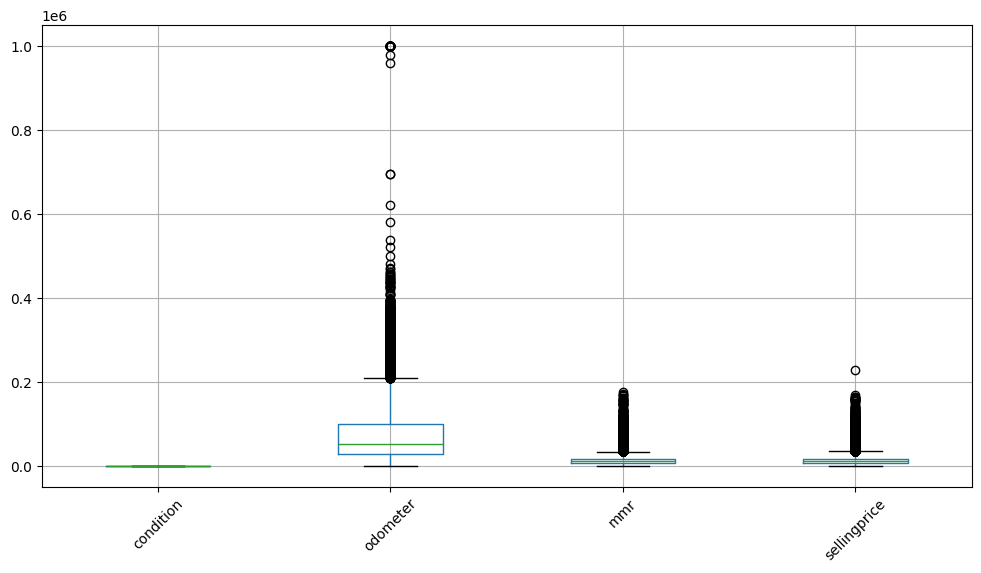

In [11]:
df[numeric_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

In [13]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = (outlier_count / len(df)) * 100

    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")

condition: 0 outliers (0.00%)
odometer: 7135 outliers (1.68%)
mmr: 11614 outliers (2.73%)
sellingprice: 11375 outliers (2.67%)


In [14]:
for col in ['odometer', 'mmr', 'sellingprice']:
    print(f"\n{col}")
    print(df[col].describe())


odometer
count    425608.000000
mean      69648.396750
std       54259.104653
min           1.000000
25%       28621.000000
50%       53575.000000
75%      101578.000000
max      999999.000000
Name: odometer, dtype: float64

mmr
count    425608.000000
mean      13471.910949
std        9440.317180
min          25.000000
25%        6725.000000
50%       12150.000000
75%       18000.000000
max      176000.000000
Name: mmr, dtype: float64

sellingprice
count    425608.000000
mean      13310.943110
std        9518.574805
min           1.000000
25%        6500.000000
50%       12000.000000
75%       17900.000000
max      230000.000000
Name: sellingprice, dtype: float64


In [20]:
df[df['mmr'] > 100000][
    ['year', 'make', 'model', 'mmr', 'sellingprice']
].sort_values('mmr', ascending=False).head(20)

,year,make,model,mmr,sellingprice
146917,2014,BMW,i8,176000.0,165000.0
239360,2014,BMW,i8,172000.0,160000.0
239357,2014,BMW,i8,170000.0,159000.0
283534,2014,BMW,i8,170000.0,165000.0
194349,2011,Rolls-Royce,Ghost,166000.0,163000.0
301118,2014,BMW,i8,163000.0,158000.0
302792,2011,Rolls-Royce,Ghost,162000.0,143000.0
363766,2014,BMW,i8,161000.0,161000.0
194367,2011,Rolls-Royce,Ghost,160000.0,149000.0
12948,2010,Rolls-Royce,Ghost,157000.0,149800.0


In [44]:
print(df.duplicated().sum())

0


In [23]:
print(df.nunique())

year                34
make                96
model              958
trim              1898
body                50
transmission         3
vin             418742
state               42
condition           41
odometer        159234
color               24
interior            17
seller           12493
mmr               1089
sellingprice      1705
saledate          3380
dtype: int64


In [24]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


make:
make
Ford          79336
Chevrolet     46663
Nissan        39690
Toyota        29773
Dodge         23749
              ...  
ford tk           1
chev truck        1
airstream         1
dot               1
Lotus             1
Name: count, Length: 96, dtype: int64

model:
model
Altima      22640
F-150       10936
Fusion       9720
Camry        9268
Escape       9062
            ...  
cherokee        1
tahoe           1
aveo            1
golf            1
comm            1
Name: count, Length: 958, dtype: int64

trim:
trim
Base                50575
SE                  33152
LX                  16435
Limited             14070
XLT                 12979
                    ...  
GLS VR6 (1999.5)        1
Touring Fleet           1
2.0XT Premium           1
GS-R                    1
750iL                   1
Name: count, Length: 1898, dtype: int64

body:
body
Sedan                      193724
SUV                        109089
Minivan                     19807
Hatchback                  

In [25]:
df[df["transmission"] == "Sedan"]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
408161,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj4fm201708,34.0,46.0,4802,silver,gray,12150.0,13200.0,16500
417835,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm258506,34.0,1.0,9410,white,gray,12150.0,13300.0,10500
421289,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj3fm276741,34.0,46.0,1167,blue,black,12150.0,13200.0,12700
424161,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm285365,34.0,1.0,2172,gray,black,12150.0,14050.0,8250


In [26]:
print(df.columns.tolist())

['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


In [27]:
print(df.iloc[0])

year                                               2015
make                                                Kia
model                                           Sorento
trim                                                 LX
body                                                SUV
transmission                                  automatic
vin                                   5xyktca69fg566472
state                                                ca
condition                                           5.0
odometer                                        16639.0
color                                             white
interior                                          black
seller                          kia motors america  inc
mmr                                             20500.0
sellingprice                                    21500.0
saledate        Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
Name: 0, dtype: object


In [28]:
df["body"] = df["body"].str.strip().str.lower()

In [29]:
df.loc[df["transmission"] == "Sedan", "transmission"] = pd.NA

In [30]:
df.loc[df["vin"] == "automatic", "vin"] = pd.NA

In [31]:
mask = df["color"].str.match(r"^\d+$", na=False)
df.loc[mask, "color"] = pd.NA

In [32]:
# Find invalid state values
invalid_state = df["state"].str.len() != 2

# Replace invalid values with NaN
df.loc[invalid_state, "state"] = pd.NA

In [39]:
df["color"] = df["color"].replace("—", pd.NA)

In [33]:
print(df["transmission"].value_counts(dropna=False))
print(df["state"].value_counts(dropna=False))
print(df["vin"].value_counts(dropna=False))
print(df["color"].value_counts(dropna=False))

transmission
automatic    412130
manual        13474
<NA>              4
Name: count, dtype: int64
state
fl      61747
ca      58936
pa      38623
tx      34327
ga      26342
nj      20015
nc      18018
il      17979
tn      17313
oh      16482
mo      12628
mi      11273
va      10022
nv       9886
md       9026
wi       7629
mn       7182
az       6684
wa       5606
co       5551
ma       4935
ny       4261
ne       3276
in       3139
sc       3098
on       2360
pr       2130
la       1869
ut       1489
hi        982
qc        909
or        887
ab        641
ms        239
ok         48
nm         37
al         26
ns          9
<NA>        4
Name: count, dtype: int64
vin
wbanv13588cz57827    5
<NA>                 4
1ftfw1cv5afb30053    4
5uxfe43579l274932    4
1fafp42r94f131221    3
                    ..
3gcpcse02cg194864    1
1g1pc5sh1c7333155    1
1g1pf5sc7c7119279    1
3gcpcse05cg276720    1
1g1zc5e0xcf112948    1
Name: count, Length: 418742, dtype: int64
color
black        84666

In [40]:
print(df.isnull().sum())

year                0
make                0
model               0
trim                0
body                0
transmission        0
vin                 0
state               0
condition           0
odometer            0
color           19024
interior            0
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64


In [43]:
print(df.isnull().sum())

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


In [47]:
df["saledate"] = pd.to_datetime(
    df["saledate"],
    errors="coerce",
    utc=True
)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425608 entries, 0 to 425607
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   year          425608 non-null  int64              
 1   make          425608 non-null  object             
 2   model         425608 non-null  object             
 3   trim          425608 non-null  object             
 4   body          425608 non-null  object             
 5   transmission  425608 non-null  object             
 6   vin           425608 non-null  object             
 7   state         425608 non-null  object             
 8   condition     425608 non-null  float64            
 9   odometer      425608 non-null  float64            
 10  color         425608 non-null  object             
 11  interior      425608 non-null  object             
 12  seller        425608 non-null  object             
 13  mmr           425608 non-null  float64      

In [49]:
df.to_csv("cleaned_car_sales.csv", index=False)

In [50]:
from google.colab import files

files.download("cleaned_car_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>